<a href="https://colab.research.google.com/github/PauloRadatz/opendss-python-examples/blob/main/presentations/ieee_et_pes_pels_joint_chapter_workshop/02_load_level_sweep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2 — Why Python automation matters: load level sweep

In Notebook 1 we replicated a run file in Python. That alone does not show why Python is worth the effort. The real value shows up when we want to repeat the same study under many conditions — that is when typing commands by hand stops being practical.

In this notebook we run the **same feeder under many load levels** (peak, off-peak, and several points in between) and collect the results in a single table and plot. Doing this by hand in OpenDSS would mean editing `loadmult`, clicking solve, copying numbers, nine times in a row. With a Python loop it is one cell.

## Setup

In [ ]:
!pip install py-dss-interface
!git clone https://github.com/PauloRadatz/opendss-python-examples.git
%cd opendss-python-examples

Cloning into 'opendss-python-examples'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 159 (delta 56), reused 95 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (159/159), 1023.03 KiB | 3.61 MiB/s, done.
Resolving deltas: 100% (56/56), done.
/content/opendss-python-examples/feeder_models/IEEETestCases/123Bus/opendss-python-examples


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import py_dss_interface

dss_file= "/content/opendss-python-examples/feeder_models/IEEETestCases/123Bus/IEEE123Master.dss"

print(f"Master file: {dss_file}")

dss = py_dss_interface.DSS()
print(f"OpenDSS started: {dss.started}")

Master file: /content/opendss-python-examples/feeder_models/IEEETestCases/123Bus/IEEE123Master.dss
OpenDSS started: True


## Define the load levels we want to study

We sweep `loadmult` from a light off-peak condition (0.2) up to peak load (1.0) in steps of 0.1. Nine power flows in total — easy in Python, painful by hand.

In [ ]:
load_multipliers = [round(0.2 + 0.1 * i, 2) for i in range(9)]
print(load_multipliers)

[0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


## Loop: compile, set load, solve, read results

For each load level we recompile the feeder, set `loadmult`, solve a snapshot, and capture 2 metrics:

- minimum voltage on the feeder (pu)
- active power at the feederhead (kW)

Recompiling each time guarantees a clean state — that is the safest pattern when sweeping conditions.

In [ ]:
results = []

for load_mult in load_multipliers:
    dss.text(f"compile [{dss_file}]")
    dss.text(f"set loadmult={load_mult}")
    dss.text("solve")

    voltages_pu = dss.circuit.buses_vmag_pu
    p_kw, _ = dss.circuit.total_power

    results.append({
        "Load multiplier": load_mult,
        "Feederhead P (kW)": -p_kw,
        "Min voltage (pu)": min(voltages_pu),
    })

results_df = pd.DataFrame(results)
results_df

,Load multiplier,Feederhead P (kW),Min voltage (pu)
0,0.2,711.452412,0.994915
1,0.3,1063.047645,0.988968
2,0.4,1419.809743,0.989218
3,0.5,1774.294645,0.983327
4,0.6,2136.004064,0.983447
5,0.7,2502.444826,0.983627
6,0.8,2871.078054,0.982286
7,0.9,3240.609422,0.980700
8,1.0,3615.241896,0.979211


## Plot min voltage vs. load level

The horizontal reference line mark the typical 0.95 pu minimum allowed voltage.

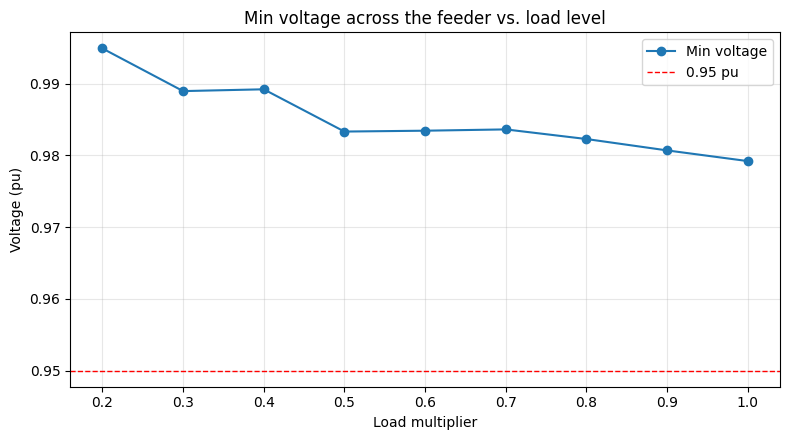

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(results_df["Load multiplier"], results_df["Min voltage (pu)"], marker="o", label="Min voltage")
ax.axhline(0.95, color="red", linestyle="--", linewidth=1, label="0.95 pu")
ax.set_xlabel("Load multiplier")
ax.set_ylabel("Voltage (pu)")
ax.set_title("Min voltage across the feeder vs. load level")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Notice min voltage barely moves across a 5× change in load — that is the seven regulators on this feeder doing their job. Without them, the curve would slope much more steeply.

## Key takeaways

- The same `compile / set loadmult / solve / read results` pattern from Notebook 1 is now wrapped in a `for` loop. Nothing more.
- Once the workflow lives in Python, sweeping one parameter (load level) is a few lines. Sweeping two (load and PV penetration, for example) is the same loop with one more dimension.
- By leveraging Python's rich ecosystem, especially libraries like `pandas` for data handling and `matplotlib` for visualization, we can effectively analyze and present results. These powerful abstractions allow us to answer specific questions with appropriate tools.

This is the practical reason Python pairs well with OpenDSS: studies that would be tedious by hand become straightforward, and the analysis is reproducible the next time we open the notebook.

## Additional learning resources

If you would like to continue learning OpenDSS and Python for power-system studies, you can find more educational materials and courses here:

- [OpenDSS courses](https://www.pauloradatz.me/opendss-courses)

## Contact

For questions or follow-up about these materials:

- Paulo Radatz
- Email: [paulo.radatz@gmail.com](mailto:paulo.radatz@gmail.com)
- LinkedIn: [linkedin.com/in/pauloradatz](https://www.linkedin.com/in/pauloradatz/)
- Website: [pauloradatz.me](https://www.pauloradatz.me/)